# Goal of the project
The goal of this project is to learn a policy for an inverted pendulum model to make it do a swing-up motion. Beyond the task of inverting a pendulum, the goal is to also gain an understanding on how Q-learning works, its limitations and advantages.

To make the problem interesting, the inverted pendulum has a limit on the maximum torque it can apply, therefore it is necessary for the pendulum to do a few "back and forth" motions to be able to reach the inverted position ($\theta=\pi$) from the standing still non-inverted position ($\theta=0$). 

<img src='pendulum.png' width="120">

In the following, we will write $x = \begin{pmatrix} \theta \\ \omega \end{pmatrix}$ as the vector of states of the system. We will also work with time-discretized dynamics, and refer to $x_n$ as the state at time $t = n \Delta t$ (assuming discretization time $\Delta t$)

We want to minimize the following discounted cost function
$\\\sum_{i=0}^{\infty} \alpha^i g(x_i, u_i)\\$ where 
$\\g(x_i, u_i) = (\theta-\pi)^2 + 0.01 \cdot \dot{\theta}_i^2 + 0.0001 \cdot u_i^2 \qquad \textrm{and} \qquad\alpha=0.99\\$
This cost mostly penalizes deviations from the inverted position but also encourages small velocities and control.

## Q-learning with a table
In the first part, we will implement the Q-learning algorithm with a table. To that end, we are given a robot (defined in the package ```pendulum.py```) with a function ```get_next_state(x,u)``` that returns $x_{n+1}$ given $(x_n, u_n)$. We will assume that $u$ can take only three possible values. Note that $\theta$ can take any value in $[0,2\pi)$ and that $\omega$ can take any value between $[-6,6]$. 

In order to build the table, we will need to discretize the states. So for the learning algorithm we will use 50 discretized states for $\theta$ and 50 for $\omega$. Keep in mind that the real states of the pendulum used to generate an episode will not be discretized.


1. Write a function ```get_cost(x,u)``` that returns the current cost $g(x,u)$ as a function of the current state and control.

2. What is the dimension of the Q-table that you will need to implement (as a numpy array)? Why?

3. How can you compute the optimal policy from the Q-table? And the optimal value function? Write a function ```get_policy_and_value_function(q_table)``` that computes both given a Q-table as an input.

4. Write a function ```q_learning(q_table)``` that implements the tabular Q-learning algorithm (use episodes of 100 timesteps and an epsilon greedy policy with $\epsilon=0.1$). The function should get as an input an initial Q-table  and return a learned Q-table of similar size. Use the function ```get_next_state``` from the pendulum package to generate the episode (do not discretize the real state of the pendulum!). During learning store the cost per episode to track learning progress.

5. How many epsilodes (approximately) does it take for Q-learning to learn how to invert the pendulum when $u \in \{-4,0,4\}$? (use a learning rate of 0.1). Show the learning progress in a plot.

6. Using the simulate / animate functions (cf. below) how many back and forth of the pendulum are necessary to go from $x = [0,0]$ to the fully inverted position? Plot the time evolution of $\theta$ and $\omega$. 

7. Plot the found policy and value function as 2D images (cf. below).

8. Answer questions 5 to 7 when using $u \in \{-5,0,5\}$. What quantitative differences do you see between the computed policies in 5. and 8.? Can you explain?

9. How is learning affected when changing $\epsilon$ and the learning rate? Why?

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pendulum
import random

def save_plt(title, flag=True):
    if flag:
        plt.savefig(f'data_viz/{title}-505.png')

def save_animate(title, animate_object, flag=True):
    my_anim, fps = animate_object
    if flag:
        my_anim.save(f'data_viz/{title}-505.mp4', writer='ffmpeg', fps=30, dpi=200)


# Option A: Save as MP4 (Requires FFmpeg)
#anim.save('my_animation.mp4', writer='ffmpeg', fps=30, dpi=200)

# Option B: Save as GIF (Requires Pillow)
#anim.save('my_animation.gif', writer='pillow', fps=30, dpi=100)

In [2]:
# we can get the integration step used in the simulation
print(f'dt is {pendulum.DELTA_T}')

# we can get the size of its state and control vector
print(f'number of states {pendulum.NUMBER_STATES} and number of controls {pendulum.NUMBER_CONTROLS}')
print('the states are indexed as follows: theta, omega')

# we can get the maximum velocity of the pendulum (omega)
print(f'the max velocity is {pendulum.MAX_VELOCITY} rad/seconds')

dt is 0.1
number of states 2 and number of controls 1
the states are indexed as follows: theta, omega
the max velocity is 6.0 rad/seconds


In [3]:
# the next_state function allows to compute the next state given a current state and action
# This is going to be very helpful to run an episode!

# assume we set x = [theta, omega] = [0,0] and u = 5, we can get the next state using
#x = np.array([0.,0.])
#u = 5
#x_next = pendulum.get_next_state(x, u)
#print(f'the next state is {x_next}')

In [4]:
#Discretizing State
discretized_theta = np.linspace(0, 2*np.pi, 50, endpoint=False)
discretized_omega = np.linspace(-6, 6, 50)

#Intialized variables
epsilon = 0.1
gamma = 0.1 #0.1
alpha = 0.99
controls = np.array([-5,0,5])
timestamp = 100
episodes = 6500 #5000

In [5]:
def get_cost(x,u):
    theta = x[0]
    theta_dot = x[1]
    current_cost = ((theta-np.pi)**2) + (0.01 * theta_dot**2) + (0.0001 * u**2)
    return current_cost

def index_in_discretized_state(state):
    index_in_discretized_theta = np.argmin(np.abs(discretized_theta - state[0]))
    index_in_discretized_omega = np.argmin(np.abs(discretized_omega - state[1]))
    return index_in_discretized_theta, index_in_discretized_omega



In [6]:


def q_learning(q_table,x0):
    x = x0
    get_cost_sum=0
    for t in range(0,timestamp): #100
        #converting state to closest discretized index
        i, j = index_in_discretized_state(x)
        
        # choosing action
        u_t_pre = minimization_and_argument(q_table,i,j)[0]    
        #u_options = [u_t_pre, random.choice(range(len(controls)))]
        u_options = [u_t_pre, np.random.choice([0,1,2])]
        epsilon_probabilities = [1-epsilon, epsilon]
        #u_t = random.choices(u_options, weights=epsilon_probabilities)
        u_t = np.random.choice(u_options, p=epsilon_probabilities)

        x_next = pendulum.get_next_state(x,controls[u_t])
        i_next, j_next = index_in_discretized_state(x_next)
        get_cost_sum += get_cost(x,controls[u_t])
        pre_TD_error=(get_cost(x,controls[u_t])) + (alpha * np.min((q_table[u_t,i_next,j_next])))
        q_table[u_t,i,j] = q_table[u_t,i,j] * (1-gamma) + gamma * pre_TD_error
        #q_table[u_t,i,j] = (Q_t[u_t,i,j] + gamma * (get_cost(x,controls[u_t]))) + (alpha * np.min((Q_t[u_t,i_next,j_next]))) - Q_t[u_t,i,j]
        x = x_next
        
    return q_table, get_cost_sum

def get_policy_and_value_function(q_table):    
    value_function = np.zeros((50,50))
    policy = np.zeros((50,50))
    for i in range(len(discretized_theta)):
        for j in range(len(discretized_omega)):
            Q_u, a = minimization_and_argument(q_table,i,j)
            value_function[i,j] = a
            policy[i,j] = controls[Q_u]
            
    return value_function,policy

def minimization_and_argument(q_table,i,j):
    a = q_table[0][i][j]
    Q_u = 0  #Used as index to select control
    for u_i in range(len(controls)):
        b = q_table[u_i][i][j]
        if a > b:
            a = b
            Q_u = u_i
    return Q_u , a
          

In [7]:
# we can also simulate the robot but we need to provide a controller of the following form
q_table = np.zeros((3,50,50))
q_table_next_store = np.zeros((episodes,3,50,50))
cost_sum_store = np.zeros((episodes))

# initial state for the episode
x0 = np.array([0,0])
for n in range(episodes):
    q_table_next,cost_sum = q_learning(q_table,x0)
    q_table_next_store[n][:][:][:] = (q_table_next)
    cost_sum_store[n] = (cost_sum)

value_function,policy = get_policy_and_value_function(q_table_next)  

def dummy_controller(x):
    """
        the prototype of a controller is as follows
        x is a column vector containing the state of the robot
        
        this controller needs to return a scalar
        you may want to modify this controller to use the policy table to compute control output
    """
    theta_index,omega_index = index_in_discretized_state(x)
    u= policy[theta_index, omega_index]
    return u


# we can now simulate for a given number of time steps - here we do 10 seconds
T = 10.
#x0 = np.array([1.4,0.])
print(x0)
t, x, u = pendulum.simulate(x0, dummy_controller, T)

[0 0]


In [13]:
#Test Episodes
n1 = np.array([0,0])
n2 = np.array([0,0])

for n in range(episodes-1,0,-1):
    #print(n)
    #if (n< 2700):
    #    q_table_next_store_diff = q_table_next_store[-1][:][:][:] - q_table_next_store[n][:][:][:]
    #    #print(np.allclose(q_table_next_store[-1][:][:][:], q_table_next_store[n][:][:][:], rtol=1e-05,atol=5e1))
    #    #print(q_table_next_store_diff)

    if np.allclose(q_table_next_store[n][:][:][:], q_table_next_store[-1][:][:][:], rtol=100e-05,atol=10e1) == False: #consider atol based on number of iterations
        q_table_next_store_diff = q_table_next_store[-1][:][:][:] - q_table_next_store[n][:][:][:]
        #print(q_table_next_store_diff)
        n2[1]=n
        break

print(f'It takes {n2[1]} episodes for Q-learning to learn how to invert the pendulum.')

It takes 3033 episodes for Q-learning to learn how to invert the pendulum.


/workspaces/optlearningcontrol/.venv/lib/python3.9/site-packages/numpy/lib/polynomial.py:666: RuntimeWarning: overflow encountered in multiply
  scale = NX.sqrt((lhs*lhs).sum(axis=0))
/workspaces/optlearningcontrol/.venv/lib/python3.9/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/workspaces/optlearningcontrol/.venv/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3550: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


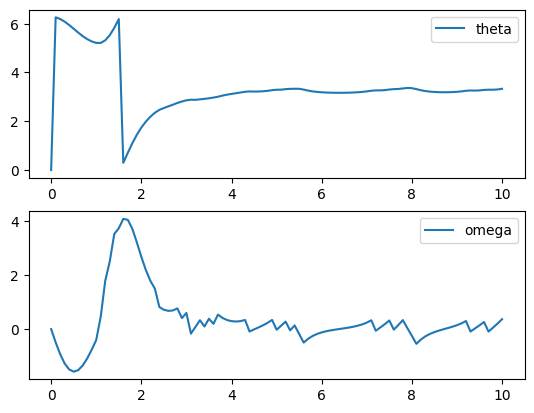

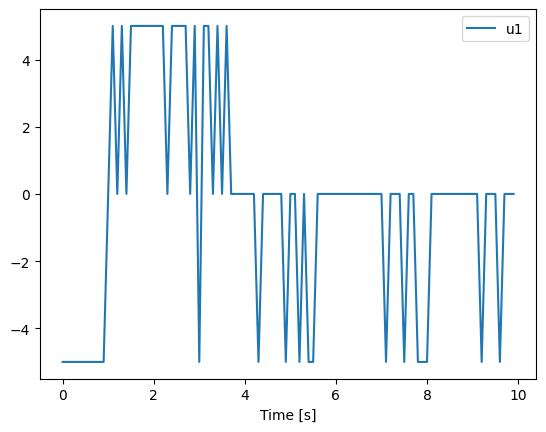

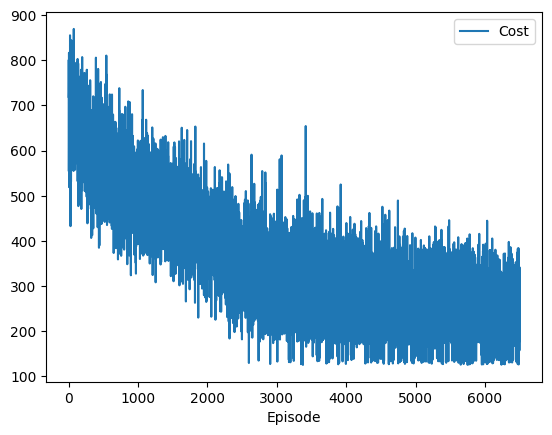

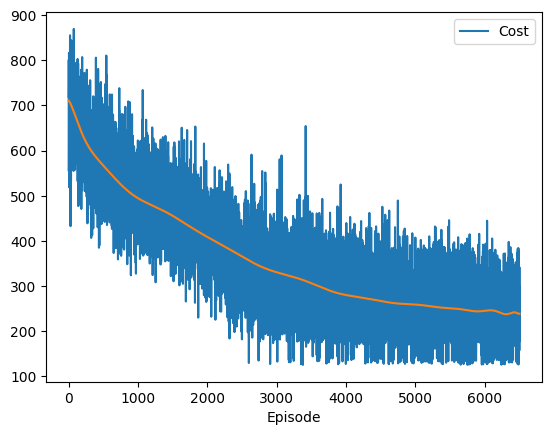

In [14]:
# we can plot the results
plt.figure()

plt.subplot(2,1,1)
plt.plot(t, x[0,:])
plt.legend(['theta'])

plt.subplot(2,1,2)
plt.plot(t, x[1,:])
plt.legend(['omega'])
save_plt(title="theta and omega vs time")

# we can also plot the control
plt.figure()
plt.plot(t[:-1], u.T)
plt.legend(['u1'])
plt.xlabel('Time [s]')
save_plt(title="control vs time")

#Learning Progress Plot
plt.figure()
plt.plot(range(episodes),cost_sum_store)
plt.legend(['Cost'])
plt.xlabel('Episode')
save_plt(title="Learning Progress")

#Extra Plot with curve fitting
z = np.polyfit(range(episodes), cost_sum_store, 80)
p = np.poly1d(z)
#p30 = np.poly1d(np.polyfit(range(episodes), cost_sum_store, 30))
xp = np.linspace(0, episodes, episodes+1)

plt.figure()
#plt.plot(range(episodes), cost_sum_store, '-', xp, p(xp), '-', xp, p30(xp), '--')
plt.plot(range(episodes), cost_sum_store, '-', xp, p(xp), '-')
plt.legend(['Cost'])
plt.xlabel('Episode')
save_plt(title="Learning Progress with curve fitting")

In [15]:
# now we can also create an animation
#pendulum.animate_robot(x)
save_animate('my_animation', pendulum.animate_robot(x,True))

Your browser does not support the video tag.

We also need to discretize the state space, we discretize $\theta \in [0, 2\pi]$ in 50 states and $\dot{\theta} \in [-6, 6]$ is 50 states. For example:

In [16]:
# we don't want 2pi to be in the set because it's the same as 0
# we generate 50 equally spaced points for theta
discretized_theta = np.linspace(0, 2*np.pi, 50, endpoint=False)

# we generate 50 equally spaced points for omega
discretized_omega = np.linspace(-6, 6, 50)

# now given an arbitrary continuous state theta
theta_arbitrary = 0.6234
omega_arbitrary = 1.234

# we can find the index of the closest element in the set of discretized states
index_in_discretized_theta = np.argmin(np.abs(discretized_theta - theta_arbitrary))
index_in_discretized_omega = np.argmin(np.abs(discretized_omega - omega_arbitrary))

# and find the closed discretized state
closest_theta_state = discretized_theta[index_in_discretized_theta]
closest_omega_state = discretized_omega[index_in_discretized_omega]

print(f'the discretized theta closest to {theta_arbitrary} is {closest_theta_state} with index {index_in_discretized_theta}')
print(f'the discretized omega closest to {omega_arbitrary} is {closest_omega_state} with index {index_in_discretized_omega}')

the discretized theta closest to 0.6234 is 0.6283185307179586 with index 5
the discretized omega closest to 1.234 is 1.3469387755102042 with index 30


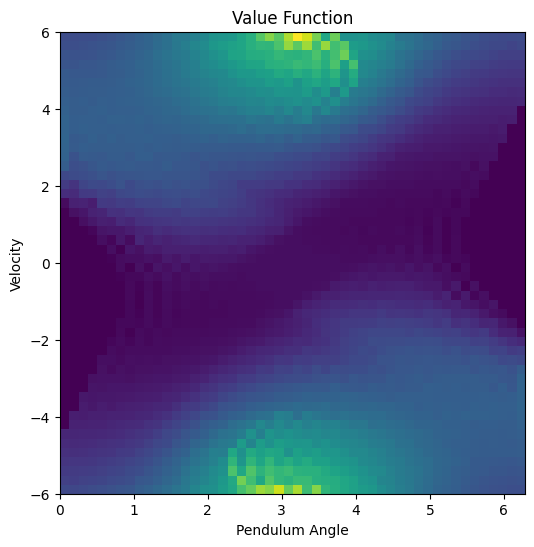

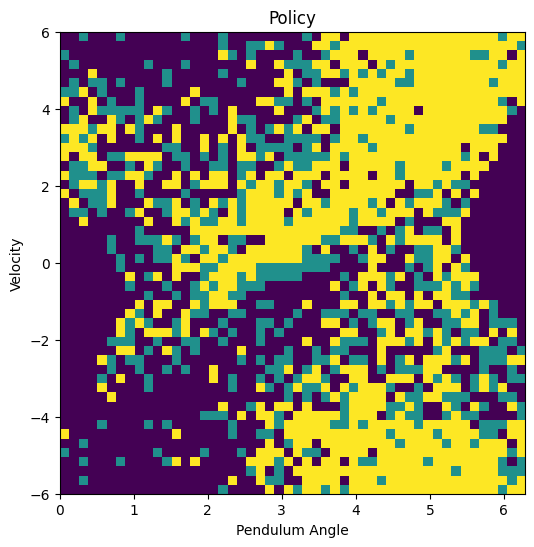

In [17]:
# here is some code to plot results, assuming a policy and a value function are given
# this can be used to answer questions in both Part 1 and 2

#value_function = vf
#policy = p

#print(value_function.size)
#print(policy.size)
#v_f,pol = get_policy_and_value_function(q_table_next)
#
#print(v_f.shape)
#print(pol.shape)

# we plot the value function
plt.figure(figsize=[6,6])
plt.imshow(value_function, extent=[0., 2*np.pi, -6, 6], aspect='auto')
plt.xlabel('Pendulum Angle')
plt.ylabel('Velocity')
plt.title('Value Function')
save_plt(title="Value Function")

# we plot the policy
plt.figure(figsize=[6,6])
plt.imshow(policy, extent=[0., 2*np.pi, -6, 6], aspect='auto')
plt.xlabel('Pendulum Angle')
plt.ylabel('Velocity')
plt.title('Policy')
save_plt(title="Policy")